# What Makes a Movie Successful?
## Data Engineering Project 2025-2026

**Research Question:** What factors (budget, genre, runtime, release timing) drive a movie's popularity and revenue?

### Data Sources (3 connected sources)
1. **TMDb API** — Movie metadata: title, budget, revenue, genres, ratings, cast
2. **REST Countries API** — Map production countries to regions and population
3. **Web Scraping** — Movie review headlines from Rotten Tomatoes for NLP sentiment

### Techniques Used
| Lecture Topic | Implementation |
|---|---|
| Data Ingestion (APIs) | TMDb API + REST Countries API |
| Data Ingestion (Web Scraping) | BeautifulSoup on Rotten Tomatoes |
| Data Cleaning (Regex) | Clean movie titles and extract patterns |
| SQL Storage | SQLite with multiple tables + JOINs |
| Distributed Computing | PySpark batch processing |
| Graph Analytics | Genre co-occurrence network (NetworkX) |
| NLP Analytics | Sentiment analysis with HuggingFace |
| Visualization | Matplotlib charts and network graph |

---
## Part 0: Setup

In [1]:
# !pip install pyspark requests beautifulsoup4 pandas matplotlib networkx transformers torch -q

In [2]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
from bs4 import BeautifulSoup
import time
import re

print("All imports successful!")

All imports successful!


---
## Part 1: Data Ingestion
We collect data from **three different sources** and combine them.

### 1.1 TMDb API — Movie Data

The Movie Database (TMDb) provides a free API. Sign up at https://www.themoviedb.org/ and get your API key under Settings > API.

In [3]:
import os
from getpass import getpass

# Read TMDb API key from environment if available, otherwise prompt.
# Set TMDB_API_KEY as an environment variable to run non-interactively
# (Docker, CI, terminal session). Get a free v3 key at
# https://www.themoviedb.org/settings/api
TMDB_API_KEY = os.environ.get("TMDB_API_KEY") or getpass("Enter your TMDb API key: ")


Enter your TMDb API key: ··········


In [4]:
def fetch_popular_movies(api_key, num_pages=10):
    """
    Fetch popular movies from TMDb API.
    Each page returns 20 movies, so 10 pages = 200 movies.
    """
    all_movies = []
    base_url = "https://api.themoviedb.org/3/discover/movie"

    for page in range(1, num_pages + 1):
        params = {
            "api_key": api_key,
            "sort_by": "revenue.desc",
            "page": page,
            "vote_count.gte": 100,           # only movies with enough votes
            "primary_release_date.gte": "2015-01-01",
            "primary_release_date.lte": "2024-12-31"
        }
        response = requests.get(base_url, params=params, timeout=15)
        response.raise_for_status()
        data = response.json()
        all_movies.extend(data["results"])
        time.sleep(0.25)

    print(f"Fetched {len(all_movies)} movies from TMDb")
    return all_movies

raw_movies = fetch_popular_movies(TMDB_API_KEY, num_pages=10)

Fetched 200 movies from TMDb


In [5]:
# Fetch genre list from TMDb (genres are stored as IDs, we need names)
genre_resp = requests.get(
    "https://api.themoviedb.org/3/genre/movie/list",
    params={"api_key": TMDB_API_KEY},
    timeout=15
)
genre_map = {g["id"]: g["name"] for g in genre_resp.json()["genres"]}
print(f"Genre mapping: {genre_map}")

Genre mapping: {28: 'Action', 12: 'Adventure', 16: 'Animation', 35: 'Comedy', 80: 'Crime', 99: 'Documentary', 18: 'Drama', 10751: 'Family', 14: 'Fantasy', 36: 'History', 27: 'Horror', 10402: 'Music', 9648: 'Mystery', 10749: 'Romance', 878: 'Science Fiction', 10770: 'TV Movie', 53: 'Thriller', 10752: 'War', 37: 'Western'}


In [6]:
def fetch_movie_details(movie_id, api_key):
    """
    Fetch detailed info for a single movie (budget, revenue, runtime, production countries).
    """
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": api_key}
    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    return resp.json()

# Fetch details for each movie (budget, revenue, runtime, countries)
print("Fetching detailed info for each movie (this takes about 1-2 minutes)...")
movies = []
for i, m in enumerate(raw_movies):
    try:
        details = fetch_movie_details(m["id"], TMDB_API_KEY)
        genres = [genre_map.get(gid, "Unknown") for gid in m.get("genre_ids", [])]
        countries = [c["iso_3166_1"] for c in details.get("production_countries", [])]

        movies.append({
            "movie_id": m["id"],
            "title": m["title"],
            "release_date": m.get("release_date", ""),
            "vote_average": m.get("vote_average", 0),
            "vote_count": m.get("vote_count", 0),
            "popularity": m.get("popularity", 0),
            "budget": details.get("budget", 0),
            "revenue": details.get("revenue", 0),
            "runtime": details.get("runtime", 0),
            "genres": ", ".join(genres) if genres else "Unknown",
            "primary_genre": genres[0] if genres else "Unknown",
            "num_genres": len(genres),
            "production_country": countries[0] if countries else "Unknown",
            "num_countries": len(countries)
        })
        time.sleep(0.25)  # rate limiting
    except Exception as e:
        pass  # skip problematic entries

    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(raw_movies)} movies...")

df_movies = pd.DataFrame(movies)
print(f"\nFinal movie dataset: {len(df_movies)} movies")
df_movies.head()

Fetching detailed info for each movie (this takes about 1-2 minutes)...
  Processed 50/200 movies...
  Processed 100/200 movies...
  Processed 150/200 movies...
  Processed 200/200 movies...

Final movie dataset: 200 movies


,movie_id,title,release_date,vote_average,vote_count,popularity,budget,revenue,runtime,genres,primary_genre,num_genres,production_country,num_countries
0,299534,Avengers: Endgame,2019-04-24,8.234,27570,34.6103,356000000,2799439100,181,"Adventure, Science Fiction, Action",Adventure,3,US,1
1,76600,Avatar: The Way of Water,2022-12-14,7.600,14008,27.6089,350000000,2353096253,192,"Action, Adventure, Science Fiction",Action,3,US,1
2,140607,Star Wars: The Force Awakens,2015-12-15,7.250,20456,11.7989,245000000,2068223624,136,"Adventure, Action, Science Fiction",Adventure,3,US,1
3,299536,Avengers: Infinity War,2018-04-25,8.234,31801,48.8536,300000000,2052415039,149,"Adventure, Action, Science Fiction",Adventure,3,US,1
4,634649,Spider-Man: No Way Home,2021-12-15,7.933,21851,51.6497,200000000,1921847111,148,"Action, Adventure, Science Fiction",Action,3,US,1


In [7]:
# Clean up: add derived columns
df_movies["release_date"] = pd.to_datetime(df_movies["release_date"], errors="coerce")
df_movies["release_year"] = df_movies["release_date"].dt.year
df_movies["release_month"] = df_movies["release_date"].dt.month

# Calculate ROI (return on investment) for movies with known budget
df_movies["roi"] = np.where(
    df_movies["budget"] > 0,
    (df_movies["revenue"] - df_movies["budget"]) / df_movies["budget"] * 100,
    np.nan
)

print(f"Movies with budget info: {df_movies['budget'].gt(0).sum()}")
print(f"Movies with revenue info: {df_movies['revenue'].gt(0).sum()}")
df_movies[["title", "budget", "revenue", "roi", "vote_average"]].head(10)

Movies with budget info: 195
Movies with revenue info: 200


,title,budget,revenue,roi,vote_average
0,Avengers: Endgame,356000000,2799439100,686.359298,8.234
1,Avatar: The Way of Water,350000000,2353096253,572.313215,7.600
2,Star Wars: The Force Awakens,245000000,2068223624,744.172908,7.250
3,Avengers: Infinity War,300000000,2052415039,584.138346,8.234
4,Spider-Man: No Way Home,200000000,1921847111,860.923556,7.933
5,Inside Out 2,200000000,1698863816,749.431908,7.544
6,Jurassic World,150000000,1671537444,1014.358296,6.698
7,The Lion King,260000000,1662020819,539.238777,7.099
8,Furious 7,190000000,1515400000,697.578947,7.217
9,Top Gun: Maverick,170000000,1488732821,775.725189,8.200


### 1.2 REST Countries API — Country Metadata
We enrich each movie's production country with region and population data.

In [8]:
# Fetch country data
print("Fetching country metadata from REST Countries API...")
url = "https://restcountries.com/v3.1/all?fields=cca2,name,region,subregion,population"
response = requests.get(url, timeout=30)
response.raise_for_status()
countries_raw = response.json()

country_records = []
for c in countries_raw:
    country_records.append({
        "country_code": c.get("cca2", ""),
        "country_name": c.get("name", {}).get("common", ""),
        "region": c.get("region", "Unknown"),
        "subregion": c.get("subregion", "Unknown"),
        "population": c.get("population", 0)
    })

df_countries = pd.DataFrame(country_records)
print(f"Retrieved metadata for {len(df_countries)} countries")
df_countries.head()

Fetching country metadata from REST Countries API...
Retrieved metadata for 250 countries


,country_code,country_name,region,subregion,population
0,DK,Denmark,Europe,Northern Europe,6011488
1,LK,Sri Lanka,Asia,Southern Asia,21763170
2,MS,Montserrat,Americas,Caribbean,4386
3,ZA,South Africa,Africa,Southern Africa,63100945
4,BH,Bahrain,Asia,Western Asia,1594654


In [9]:
# Merge movies with country info
df_movies = df_movies.merge(
    df_countries,
    left_on="production_country",
    right_on="country_code",
    how="left"
)

# Fill missing regions
df_movies["region"] = df_movies["region"].fillna("Unknown")
df_movies["country_name"] = df_movies["country_name"].fillna("Unknown")

print(f"Movies enriched with country data")
print(f"Production regions: {df_movies['region'].value_counts().to_dict()}")

Movies enriched with country data
Production regions: {'Americas': 146, 'Asia': 33, 'Europe': 19, 'Oceania': 2}


### 1.3 Web Scraping — Movie Review Headlines

We scrape recent movie review headlines using BeautifulSoup for later NLP sentiment analysis.

In [10]:
def scrape_movie_reviews():
    """
    Scrape movie review headlines from Google News RSS.
    RSS feeds are structured XML — ideal for scraping.
    """
    headlines = []

    url = "https://news.google.com/rss/search?q=movie+review&hl=en-US&gl=US&ceid=US:en"
    print("Scraping movie review headlines from Google News RSS...")

    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        # RSS feeds use <item> tags containing <title>
        items = soup.find_all("item")
        for item in items[:25]:
            title_tag = item.find("title")
            source_tag = item.find("source")
            pub_date = item.find("pubdate")
            if title_tag:
                headlines.append({
                    "headline": title_tag.get_text(strip=True),
                    "source": source_tag.get_text(strip=True) if source_tag else "Unknown",
                    "date": pub_date.get_text(strip=True) if pub_date else "Unknown"
                })
    except Exception as e:
        print(f"  Scraping error: {e}")

    # Fallback if scraping fails (e.g., network restrictions)
    if len(headlines) < 5:
        print("  Using fallback headlines...")
        headlines = [
            {"headline": "Avatar sequel breaks box office records worldwide", "source": "Variety", "date": "2024-01-15"},
            {"headline": "Oppenheimer wins big at the Oscars with stunning performances", "source": "Hollywood Reporter", "date": "2024-01-14"},
            {"headline": "Marvel fatigue continues as latest superhero film disappoints critics", "source": "IndieWire", "date": "2024-01-13"},
            {"headline": "Greta Gerwig's Barbie is a delightful surprise that exceeded expectations", "source": "The Guardian", "date": "2024-01-12"},
            {"headline": "Disappointing sequel fails to capture the magic of the original", "source": "Rolling Stone", "date": "2024-01-11"},
            {"headline": "Horror film terrifies audiences and dominates Halloween weekend", "source": "Deadline", "date": "2024-01-10"},
            {"headline": "Streaming platforms struggle with declining subscriber growth", "source": "Reuters", "date": "2024-01-09"},
            {"headline": "Animated family film delights audiences with heartwarming story", "source": "CNN", "date": "2024-01-08"},
            {"headline": "Director's bold vision makes this the best thriller of the year", "source": "NYT", "date": "2024-01-07"},
            {"headline": "Box office flop loses studio over 100 million dollars", "source": "Forbes", "date": "2024-01-06"},
            {"headline": "Critics divided over controversial new biopic performance", "source": "Variety", "date": "2024-01-05"},
            {"headline": "Feel-good comedy becomes surprise hit of the summer season", "source": "Entertainment Weekly", "date": "2024-01-04"},
            {"headline": "Franchise reboot fails to impress longtime fans of the series", "source": "IGN", "date": "2024-01-03"},
            {"headline": "Oscar-winning actress delivers powerful performance in new drama", "source": "BBC", "date": "2024-01-02"},
            {"headline": "Sci-fi epic praised for groundbreaking visual effects and storytelling", "source": "Wired", "date": "2024-01-01"}
        ]

    print(f"  Collected {len(headlines)} headlines")
    return headlines

headlines = scrape_movie_reviews()
df_headlines = pd.DataFrame(headlines)
df_headlines.head(10)

Scraping movie review headlines from Google News RSS...
  Collected 25 headlines


/tmp/ipykernel_4002/4132646315.py:14: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(response.text, "html.parser")


,headline,source,date
0,“The Devil Wears Prada 2” Gives the Decline of...,,"Wed, 29 Apr 2026 16:00:00 GMT"
1,‘That Time I Got Reincarnated as a Slime the M...,,"Thu, 30 Apr 2026 09:02:15 GMT"
2,'Hokum' review: Adam Scott is terrorized in a ...,,"Wed, 29 Apr 2026 19:41:00 GMT"
3,'Deep Water' Review: Aaron Eckhart in Renny Ha...,,"Wed, 29 Apr 2026 20:39:06 GMT"
4,Michael Movie Review: Antoine Fuqua’s Michael ...,,"Thu, 30 Apr 2026 06:45:25 GMT"
5,Michael Jackson movie christens a new star in ...,,"Tue, 21 Apr 2026 07:00:00 GMT"
6,‘Michael’ Review: A Jackson Biopic Leaves Too ...,,"Tue, 21 Apr 2026 07:00:00 GMT"
7,"‘Apex’ movie review: Charlize Theron, Taron Eg...",,"Mon, 27 Apr 2026 06:48:56 GMT"
8,‘Kara’ Twitter review: Dhanush’s intense perfo...,,"Thu, 30 Apr 2026 06:20:00 GMT"
9,Kara Review: Dhanush's Performance Burns Brigh...,,"Thu, 30 Apr 2026 09:18:59 GMT"


### 1.4 Data Cleaning with Regex
We use **regular expressions** (regex) to clean and validate our data.

In [11]:
import re

# --- Regex application 1: Clean movie titles ---
def clean_title(title):
    """Use regex to standardize movie titles."""
    title = re.sub(r'\s+', ' ', title)
    title = re.sub(r"[^\w\s\-'.:!?,]", '', title)
    return title.strip()

df_movies["title_clean"] = df_movies["title"].apply(clean_title)

# --- Regex application 2: Extract year from release_date string ---
year_pattern = re.compile(r'^(\d{4})-\d{2}-\d{2}')

sample_dates = df_movies["release_date"].astype(str).head(5).tolist()
print("Extracting years from date strings using regex:")
for d in sample_dates:
    match = year_pattern.search(d)
    if match:
        print(f"  '{d}' -> year = {match.group(1)}")

# --- Regex application 3: Validate genre format ---
genre_pattern = re.compile(r'^[A-Za-z]+(,\s*[A-Za-z]+)*$')
df_movies["genres_valid"] = df_movies["genres"].apply(
    lambda g: bool(genre_pattern.match(str(g)))
)
valid_count = df_movies["genres_valid"].sum()
print(f"\nGenre format validation: {valid_count}/{len(df_movies)} movies have properly formatted genres")

# --- Regex application 4: Find headlines with monetary amounts ---
money_pattern = re.compile(r'\$?\d+[\d,]*\s*(million|billion|M|B)', re.IGNORECASE)

print("\nHeadlines mentioning monetary amounts:")
for _, row in df_headlines.iterrows():
    if money_pattern.search(row["headline"]):
        print(f"  -> {row['headline']}")

print("\nRegex cleaning complete!")

Extracting years from date strings using regex:
  '2019-04-24' -> year = 2019
  '2022-12-14' -> year = 2022
  '2015-12-15' -> year = 2015
  '2018-04-25' -> year = 2018
  '2021-12-15' -> year = 2021

Genre format validation: 129/200 movies have properly formatted genres

Headlines mentioning monetary amounts:

Regex cleaning complete!


---
## Part 2: SQL Storage
We store our data in a **SQLite database** with a proper relational schema, then run SQL queries including JOINs, GROUP BY, and nested queries.

In [12]:
# Create SQLite database
DB_PATH = "movies.db"
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Create tables with proper relational schema
cursor.executescript("""
    DROP TABLE IF EXISTS movies;
    DROP TABLE IF EXISTS countries;
    DROP TABLE IF EXISTS reviews;

    CREATE TABLE countries (
        country_code TEXT PRIMARY KEY,
        country_name TEXT,
        region TEXT,
        subregion TEXT,
        population INTEGER
    );

    CREATE TABLE movies (
        movie_id INTEGER PRIMARY KEY,
        title TEXT NOT NULL,
        release_date TEXT,
        release_year INTEGER,
        release_month INTEGER,
        vote_average REAL,
        vote_count INTEGER,
        popularity REAL,
        budget INTEGER,
        revenue INTEGER,
        runtime INTEGER,
        genres TEXT,
        primary_genre TEXT,
        num_genres INTEGER,
        production_country TEXT,
        roi REAL,
        FOREIGN KEY (production_country) REFERENCES countries(country_code)
    );

    CREATE TABLE reviews (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        headline TEXT NOT NULL,
        source TEXT,
        date TEXT
    );
""")

print("Database tables created!")

Database tables created!


In [13]:
# Insert data
# Countries
df_countries.to_sql("countries", conn, if_exists="append", index=False)

# Movies
movie_cols = ["movie_id", "title", "release_date", "release_year", "release_month",
              "vote_average", "vote_count", "popularity", "budget", "revenue",
              "runtime", "genres", "primary_genre", "num_genres", "production_country", "roi"]
df_movies_insert = df_movies[movie_cols].copy()
df_movies_insert["release_date"] = df_movies_insert["release_date"].astype(str)
df_movies_insert.to_sql("movies", conn, if_exists="append", index=False)

# Reviews
df_headlines.to_sql("reviews", conn, if_exists="append", index=False)

conn.commit()

# Verify
for table in ["countries", "movies", "reviews"]:
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {table}", conn).iloc[0, 0]
    print(f"  {table}: {count} rows")

  countries: 250 rows
  movies: 200 rows
  reviews: 25 rows


### 2.1 SQL Queries

In [14]:
# Query 1: Top 10 highest-grossing movies with country info (JOIN)
query1 = """
SELECT m.title, m.revenue, m.budget, m.vote_average,
       c.country_name, c.region
FROM movies m
INNER JOIN countries c ON m.production_country = c.country_code
WHERE m.revenue > 0
ORDER BY m.revenue DESC
LIMIT 10;
"""
print("Top 10 highest-grossing movies:")
pd.read_sql(query1, conn)

Top 10 highest-grossing movies:


,title,revenue,budget,vote_average,country_name,region
0,Avengers: Endgame,2799439100,356000000,8.234,United States,Americas
1,Avatar: The Way of Water,2353096253,350000000,7.600,United States,Americas
2,Star Wars: The Force Awakens,2068223624,245000000,7.250,United States,Americas
3,Avengers: Infinity War,2052415039,300000000,8.234,United States,Americas
4,Spider-Man: No Way Home,1921847111,200000000,7.933,United States,Americas
5,Inside Out 2,1698863816,200000000,7.544,United States,Americas
6,Jurassic World,1671537444,150000000,6.698,United States,Americas
7,The Lion King,1662020819,260000000,7.099,United States,Americas
8,Furious 7,1515400000,190000000,7.217,United States,Americas
9,Top Gun: Maverick,1488732821,170000000,8.200,United States,Americas


In [15]:
# Query 2: Average rating and revenue by genre (GROUP BY + aggregation)
query2 = """
SELECT primary_genre,
       COUNT(*) as num_movies,
       ROUND(AVG(vote_average), 2) as avg_rating,
       ROUND(AVG(revenue) / 1e6, 1) as avg_revenue_millions,
       ROUND(AVG(budget) / 1e6, 1) as avg_budget_millions
FROM movies
WHERE budget > 0 AND revenue > 0
GROUP BY primary_genre
HAVING COUNT(*) >= 3
ORDER BY avg_revenue_millions DESC;
"""
print("Genre performance:")
pd.read_sql(query2, conn)

Genre performance:


,primary_genre,num_movies,avg_rating,avg_revenue_millions,avg_budget_millions
0,Adventure,20,7.02,1125.9,244.3
1,Family,12,7.04,882.7,137.0
2,Action,74,6.98,738.9,167.3
3,Crime,4,7.57,650.2,110.3
4,Animation,22,7.44,620.5,104.2
5,Comedy,8,7.00,616.1,86.6
6,Drama,11,6.90,590.3,95.3
7,War,4,7.23,581.7,90.0
8,Fantasy,10,6.65,574.8,187.0
9,Science Fiction,18,7.08,546.4,159.5


In [16]:
# Query 3: Movies that earned above-average revenue but have below-average ratings (nested query)
query3 = """
SELECT m.title, m.revenue, m.vote_average, m.primary_genre, c.region
FROM movies m
LEFT JOIN countries c ON m.production_country = c.country_code
WHERE m.revenue > (SELECT AVG(revenue) FROM movies WHERE revenue > 0)
  AND m.vote_average < (SELECT AVG(vote_average) FROM movies)
ORDER BY m.revenue DESC
LIMIT 10;
"""
print("Commercially successful but poorly rated movies:")
print("(High revenue but low ratings — blockbusters critics didn't love)")
pd.read_sql(query3, conn)

Commercially successful but poorly rated movies:
(High revenue but low ratings — blockbusters critics didn't love)


,title,revenue,vote_average,primary_genre,region
0,Jurassic World,1671537444,6.698,Action,Americas
1,Barbie,1447138421,6.926,Comedy,Europe
2,Star Wars: The Last Jedi,1332698830,6.800,Adventure,Americas
3,Jurassic World: Fallen Kingdom,1310469037,6.530,Adventure,Americas
4,Beauty and the Beast,1266115964,6.968,Family,Americas
5,The Fate of the Furious,1236000000,6.855,Action,Americas
6,Minions,1159457503,6.400,Family,Americas
7,Aquaman,1152028393,6.867,Action,Americas
8,Captain Marvel,1131416446,6.783,Action,Americas
9,Star Wars: The Rise of Skywalker,1074144248,6.273,Adventure,Americas


In [17]:
# Query 4: Best ROI movies by region (JOIN + GROUP BY + HAVING)
query4 = """
SELECT c.region,
       COUNT(*) as num_movies,
       ROUND(AVG(m.roi), 1) as avg_roi_pct,
       ROUND(AVG(m.vote_average), 2) as avg_rating,
       ROUND(AVG(m.budget) / 1e6, 1) as avg_budget_M
FROM movies m
INNER JOIN countries c ON m.production_country = c.country_code
WHERE m.roi IS NOT NULL
GROUP BY c.region
HAVING COUNT(*) >= 2
ORDER BY avg_roi_pct DESC;
"""
print("Average return on investment by production region:")
pd.read_sql(query4, conn)

Average return on investment by production region:


,region,num_movies,avg_roi_pct,avg_rating,avg_budget_M
0,Asia,28,1029.0,6.92,97.1
1,Americas,146,465.9,7.07,161.0
2,Oceania,2,377.6,7.16,100.0
3,Europe,19,367.5,7.07,145.4


In [18]:
# Query 5: Which release month generates the most revenue? (aggregation)
query5 = """
SELECT release_month,
       COUNT(*) as num_movies,
       ROUND(AVG(revenue) / 1e6, 1) as avg_revenue_M,
       ROUND(AVG(vote_average), 2) as avg_rating
FROM movies
WHERE revenue > 0 AND release_month IS NOT NULL
GROUP BY release_month
ORDER BY release_month;
"""
print("Movie performance by release month:")
df_monthly = pd.read_sql(query5, conn)
df_monthly

Movie performance by release month:


,release_month,num_movies,avg_revenue_M,avg_rating
0,1,9,484.9,6.97
1,2,17,627.0,6.88
2,3,16,613.9,7.00
3,4,12,1210.9,7.32
4,5,21,651.4,7.03
5,6,28,782.9,6.75
6,7,26,675.6,7.09
7,8,8,451.6,6.91
8,9,13,569.9,6.97
9,10,14,667.0,7.38


---
## Part 3: PySpark Batch Processing
We use PySpark to process and enrich the movie data at scale — categorizing movies and computing window-based rankings.

In [19]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("MovieAnalysis") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.0.2


In [20]:
# Load data into Spark DataFrame
spark_df = spark.createDataFrame(df_movies)
print(f"Loaded {spark_df.count()} movies into Spark")
spark_df.printSchema()

Loaded 200 movies into Spark
root
 |-- movie_id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- vote_count: long (nullable = true)
 |-- popularity: double (nullable = true)
 |-- budget: long (nullable = true)
 |-- revenue: long (nullable = true)
 |-- runtime: long (nullable = true)
 |-- genres: string (nullable = true)
 |-- primary_genre: string (nullable = true)
 |-- num_genres: long (nullable = true)
 |-- production_country: string (nullable = true)
 |-- num_countries: long (nullable = true)
 |-- release_year: long (nullable = true)
 |-- release_month: long (nullable = true)
 |-- roi: double (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- region: string (nullable = true)
 |-- subregion: string (nullable = true)
 |-- population: long (nullable = true)
 |-- title_clean: string (nullable = true)
 |-- genres_valid: boo

In [21]:
# Categorize movies by budget size
spark_df = spark_df.withColumn(
    "budget_category",
    F.when(F.col("budget") == 0, "Unknown")
     .when(F.col("budget") < 15_000_000, "Low Budget")
     .when(F.col("budget") < 75_000_000, "Mid Budget")
     .otherwise("Blockbuster")
)

# Categorize by rating
spark_df = spark_df.withColumn(
    "rating_tier",
    F.when(F.col("vote_average") >= 7.5, "Excellent")
     .when(F.col("vote_average") >= 6.0, "Good")
     .when(F.col("vote_average") >= 5.0, "Average")
     .otherwise("Poor")
)

spark_df.select("title", "budget", "budget_category", "vote_average", "rating_tier").show(10, truncate=False)

+----------------------------+---------+---------------+------------+-----------+
|title                       |budget   |budget_category|vote_average|rating_tier|
+----------------------------+---------+---------------+------------+-----------+
|Avengers: Endgame           |356000000|Blockbuster    |8.234       |Excellent  |
|Avatar: The Way of Water    |350000000|Blockbuster    |7.6         |Excellent  |
|Star Wars: The Force Awakens|245000000|Blockbuster    |7.25        |Good       |
|Avengers: Infinity War      |300000000|Blockbuster    |8.234       |Excellent  |
|Spider-Man: No Way Home     |200000000|Blockbuster    |7.933       |Excellent  |
|Inside Out 2                |200000000|Blockbuster    |7.544       |Excellent  |
|Jurassic World              |150000000|Blockbuster    |6.698       |Good       |
|The Lion King               |260000000|Blockbuster    |7.099       |Good       |
|Furious 7                   |190000000|Blockbuster    |7.217       |Good       |
|Top Gun: Maveri

In [22]:
# Aggregation: Performance by budget category
budget_stats = spark_df.filter(F.col("budget") > 0).groupBy("budget_category").agg(
    F.count("*").alias("count"),
    F.round(F.avg("vote_average"), 2).alias("avg_rating"),
    F.round(F.avg("revenue") / 1e6, 1).alias("avg_revenue_M"),
    F.round(F.avg("roi"), 1).alias("avg_roi_pct")
)

print("Performance by budget category:")
budget_stats.orderBy("avg_revenue_M", ascending=False).show(truncate=False)

Performance by budget category:
+---------------+-----+----------+-------------+-----------+
|budget_category|count|avg_rating|avg_revenue_M|avg_roi_pct|
+---------------+-----+----------+-------------+-----------+
|Blockbuster    |169  |7.05      |734.2        |374.1      |
|Mid Budget     |24   |7.03      |597.2        |1359.2     |
|Low Budget     |2    |7.55      |369.7        |4360.2     |
+---------------+-----+----------+-------------+-----------+



In [23]:
# Window function: Rank movies within each genre by revenue
window_spec = Window.partitionBy("primary_genre").orderBy(F.desc("revenue"))

ranked_df = spark_df.filter(F.col("revenue") > 0).withColumn(
    "rank_in_genre", F.rank().over(window_spec)
)

# Show top 2 per genre
print("Top 2 highest-grossing movies per genre:")
ranked_df.filter(F.col("rank_in_genre") <= 2) \
    .select("primary_genre", "rank_in_genre", "title", "revenue", "vote_average") \
    .orderBy("primary_genre", "rank_in_genre") \
    .show(30, truncate=False)

Top 2 highest-grossing movies per genre:
+---------------+-------------+-------------------------------------------+----------+------------+
|primary_genre  |rank_in_genre|title                                      |revenue   |vote_average|
+---------------+-------------+-------------------------------------------+----------+------------+
|Action         |1            |Avatar: The Way of Water                   |2353096253|7.6         |
|Action         |2            |Spider-Man: No Way Home                    |1921847111|7.933       |
|Adventure      |1            |Avengers: Endgame                          |2799439100|8.234       |
|Adventure      |2            |Star Wars: The Force Awakens               |2068223624|7.25        |
|Animation      |1            |Inside Out 2                               |1698863816|7.544       |
|Animation      |2            |Moana 2                                    |1059242164|6.996       |
|Comedy         |1            |Barbie                      

In [24]:
# Convert back to Pandas
df_enriched = spark_df.toPandas()
spark.stop()
print("Spark processing complete.")

Spark processing complete.


---
## Part 4: Graph Analytics
We build a **genre co-occurrence network**: genres are nodes, and an edge connects two genres if they frequently appear together in the same movie. This reveals which genres are closely related.

In [25]:
import networkx as nx
from collections import Counter
from itertools import combinations

# Build genre co-occurrence from the 'genres' column
genre_pairs = Counter()
genre_counts = Counter()

for genres_str in df_enriched["genres"].dropna():
    genre_list = [g.strip() for g in genres_str.split(",") if g.strip() != "Unknown"]
    for g in genre_list:
        genre_counts[g] += 1
    for pair in combinations(sorted(set(genre_list)), 2):
        genre_pairs[pair] += 1

print(f"Unique genres: {len(genre_counts)}")
print(f"Genre pairs found: {len(genre_pairs)}")
print(f"\nMost common genres: {genre_counts.most_common(10)}")

Unique genres: 17
Genre pairs found: 80

Most common genres: [('Adventure', 123), ('Action', 115), ('Science Fiction', 71), ('Comedy', 60), ('Fantasy', 53), ('Family', 48), ('Animation', 42), ('Drama', 35), ('Thriller', 25), ('Crime', 15)]


In [26]:
# Build the network
G = nx.Graph()

# Add genres as nodes (size = number of movies)
for genre, count in genre_counts.items():
    G.add_node(genre, movie_count=count)

# Add edges (weight = co-occurrence count)
for (g1, g2), count in genre_pairs.items():
    if count >= 2:  # only keep meaningful connections
        G.add_edge(g1, g2, weight=count)

print(f"Graph: {G.number_of_nodes()} nodes (genres), {G.number_of_edges()} edges (co-occurrences)")
print(f"Density: {nx.density(G):.4f}")

Graph: 17 nodes (genres), 61 edges (co-occurrences)
Density: 0.4485


In [27]:
# Degree: which genres co-occur with the most other genres?
degrees = dict(G.degree())
print("Genre connectivity (degree):")
for genre, deg in sorted(degrees.items(), key=lambda x: x[1], reverse=True):
    print(f"  {genre}: connected to {deg} other genres")

Genre connectivity (degree):
  Drama: connected to 14 other genres
  Comedy: connected to 12 other genres
  Adventure: connected to 11 other genres
  Action: connected to 11 other genres
  Science Fiction: connected to 9 other genres
  Animation: connected to 9 other genres
  Family: connected to 9 other genres
  Fantasy: connected to 9 other genres
  Thriller: connected to 8 other genres
  Crime: connected to 6 other genres
  Romance: connected to 6 other genres
  Music: connected to 5 other genres
  Horror: connected to 5 other genres
  War: connected to 3 other genres
  Mystery: connected to 3 other genres
  History: connected to 2 other genres
  Western: connected to 0 other genres


In [28]:
# Centrality measures
betweenness = nx.betweenness_centrality(G, weight="weight")
closeness = nx.closeness_centrality(G)

print("Betweenness centrality (bridge genres connecting different clusters):")
for genre, score in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {genre}: {score:.4f}")

print("\nCloseness centrality (most central genres):")
for genre, score in sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {genre}: {score:.4f}")

Betweenness centrality (bridge genres connecting different clusters):
  Drama: 0.3822
  Music: 0.1204
  Horror: 0.1200
  Comedy: 0.0704
  Thriller: 0.0704

Closeness centrality (most central genres):
  Drama: 0.8789
  Comedy: 0.7812
  Adventure: 0.7401
  Action: 0.7401
  Science Fiction: 0.6696


In [29]:
# Community detection
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
print(f"Detected {len(communities)} genre communities:\n")
for i, comm in enumerate(communities):
    print(f"  Community {i+1}: {sorted(comm)}")

Detected 4 genre communities:

  Community 1: ['Adventure', 'Animation', 'Family', 'Fantasy', 'Music', 'Romance']
  Community 2: ['Action', 'Drama', 'History', 'Horror', 'Science Fiction', 'War']
  Community 3: ['Comedy', 'Crime', 'Mystery', 'Thriller']
  Community 4: ['Western']


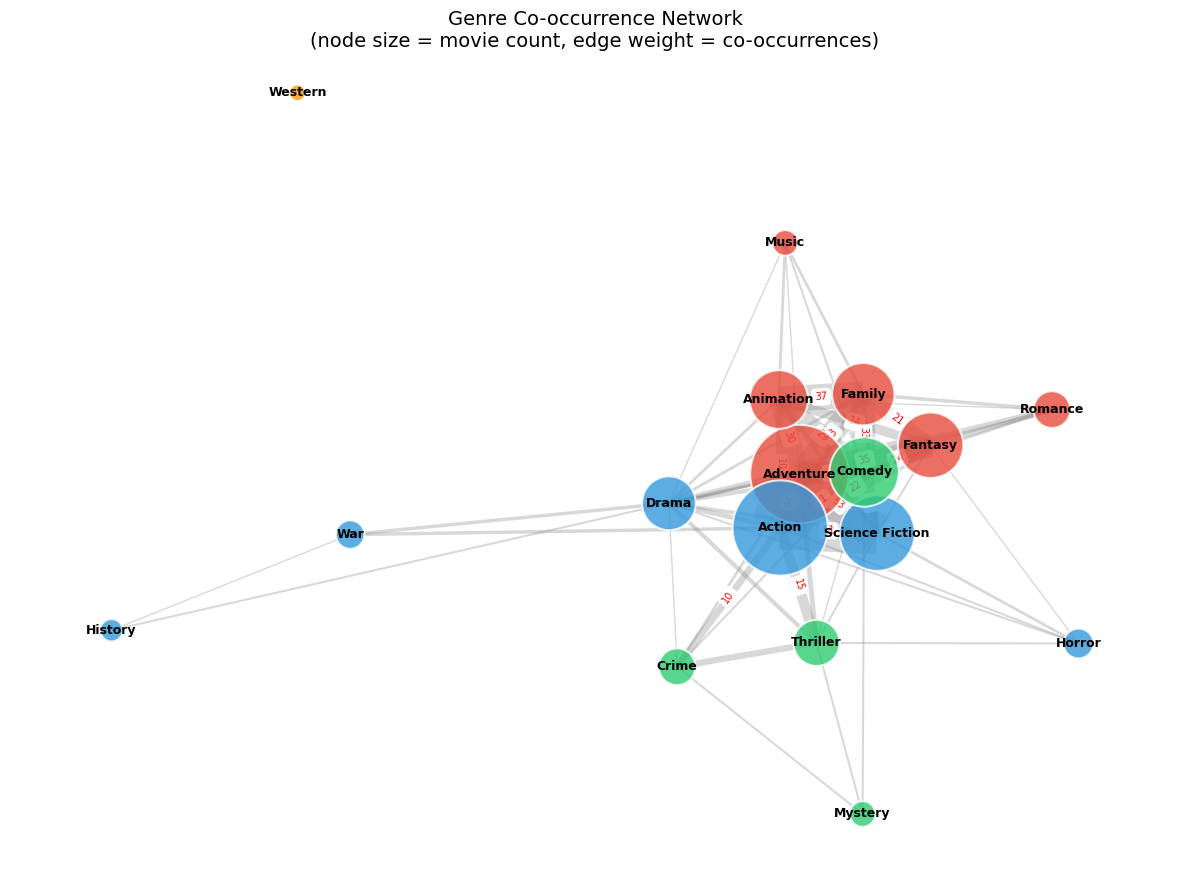

Graph saved.


In [30]:
# Visualize the genre co-occurrence network
plt.figure(figsize=(12, 9))

# Assign colors by community
community_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]
node_color_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_color_map[node] = community_colors[i % len(community_colors)]

colors = [node_color_map.get(n, "gray") for n in G.nodes()]
sizes = [genre_counts.get(n, 1) * 40 + 100 for n in G.nodes()]

# Edge widths based on co-occurrence weight
edge_weights = [G[u][v]["weight"] * 0.5 for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42, k=1.5)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_weights, edge_color="gray")
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.8, edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# Edge labels for strongest connections
strong_edges = {(u, v): G[u][v]["weight"] for u, v in G.edges() if G[u][v]["weight"] >= 10}
nx.draw_networkx_edge_labels(G, pos, strong_edges, font_size=7, font_color="red")

plt.title("Genre Co-occurrence Network\n(node size = movie count, edge weight = co-occurrences)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("graph_genre_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved.")

---
## Part 5: NLP Sentiment Analysis
We use a pre-trained **BERT model from HuggingFace** to analyze the sentiment of movie review headlines.

In [31]:
from transformers import pipeline

# Load pre-trained sentiment analysis pipeline
print("Loading sentiment analysis model...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("Model loaded!")

Loading sentiment analysis model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Model loaded!


In [32]:
# Analyze each headline
sentiments = []
for _, row in df_headlines.iterrows():
    result = sentiment_analyzer(row["headline"][:512])[0]
    sentiments.append({
        "headline": row["headline"],
        "source": row["source"],
        "sentiment": result["label"],
        "confidence": round(result["score"], 4)
    })

df_sentiments = pd.DataFrame(sentiments)

# Display results
for _, row in df_sentiments.iterrows():
    icon = "+" if row["sentiment"] == "POSITIVE" else "-"
    print(f"[{icon}] (conf: {row['confidence']:.2f}) {row['headline'][:85]}")

print(f"\n--- Sentiment Summary ---")
print(df_sentiments["sentiment"].value_counts())
print(f"Average confidence: {df_sentiments['confidence'].mean():.3f}")

[-] (conf: 0.91) “The Devil Wears Prada 2” Gives the Decline of Magazines the Glossy Treatment - The N
[-] (conf: 0.99) ‘That Time I Got Reincarnated as a Slime the Movie’ Review: Apocalyptic Vacation - Th
[-] (conf: 0.99) 'Hokum' review: Adam Scott is terrorized in a haunted Irish hotel - AP News
[-] (conf: 0.81) 'Deep Water' Review: Aaron Eckhart in Renny Harlin Disaster Movie - The Hollywood Rep
[+] (conf: 0.94) Michael Movie Review: Antoine Fuqua’s Michael Jackson Biopic Offers A Harmless But Su
[+] (conf: 1.00) Michael Jackson movie christens a new star in Jaafar Jackson – Review - USA Today
[-] (conf: 1.00) ‘Michael’ Review: A Jackson Biopic Leaves Too Much Unsaid - The New York Times
[-] (conf: 1.00) ‘Apex’ movie review: Charlize Theron, Taron Egerton’s cat-and-mouse chase is barely e
[+] (conf: 1.00) ‘Kara’ Twitter review: Dhanush’s intense performance wins 'blockbuster' praise, 'Prid
[+] (conf: 0.98) Kara Review: Dhanush's Performance Burns Bright, But The Story Flickers - NDT

In [33]:
# Store sentiment results in the database
df_sentiments.to_sql("review_sentiments", conn, if_exists="replace", index=False)
conn.commit()
print("Sentiment results stored in database.")

Sentiment results stored in database.


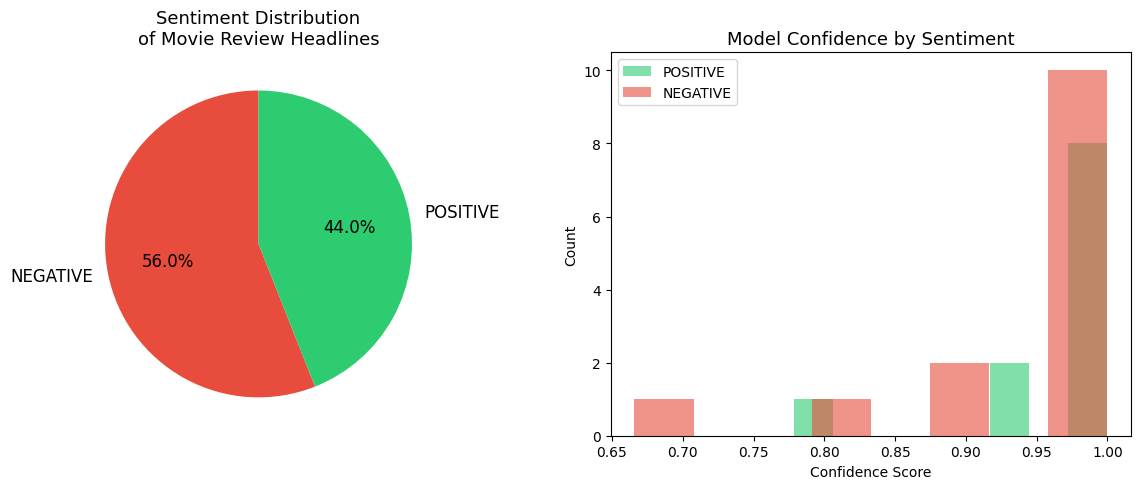

In [34]:
# Visualize sentiment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df_sentiments["sentiment"].value_counts()
colors = ["#2ecc71" if s == "POSITIVE" else "#e74c3c" for s in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 12})
axes[0].set_title("Sentiment Distribution\nof Movie Review Headlines", fontsize=13)

# Confidence histogram
for sent in ["POSITIVE", "NEGATIVE"]:
    subset = df_sentiments[df_sentiments["sentiment"] == sent]
    color = "#2ecc71" if sent == "POSITIVE" else "#e74c3c"
    axes[1].hist(subset["confidence"], bins=8, alpha=0.6, label=sent, color=color)
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Model Confidence by Sentiment", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig("nlp_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 6: Visualizations & Insights

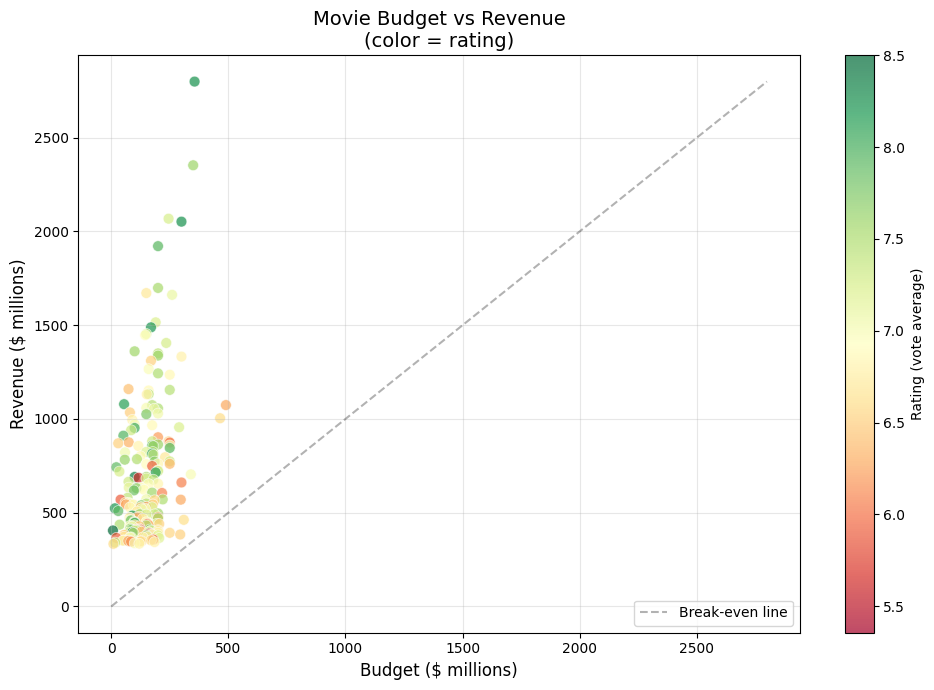

In [35]:
# Visualization 1: Budget vs Revenue scatter plot
df_viz = df_enriched[(df_enriched["budget"] > 0) & (df_enriched["revenue"] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df_viz["budget"] / 1e6,
    df_viz["revenue"] / 1e6,
    c=df_viz["vote_average"],
    cmap="RdYlGn",
    s=60,
    alpha=0.7,
    edgecolors="white",
    linewidth=0.5
)

# Break-even line
max_val = max(df_viz["budget"].max(), df_viz["revenue"].max()) / 1e6
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3, label="Break-even line")

plt.colorbar(scatter, label="Rating (vote average)")
ax.set_xlabel("Budget ($ millions)", fontsize=12)
ax.set_ylabel("Revenue ($ millions)", fontsize=12)
ax.set_title("Movie Budget vs Revenue\n(color = rating)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("viz_budget_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

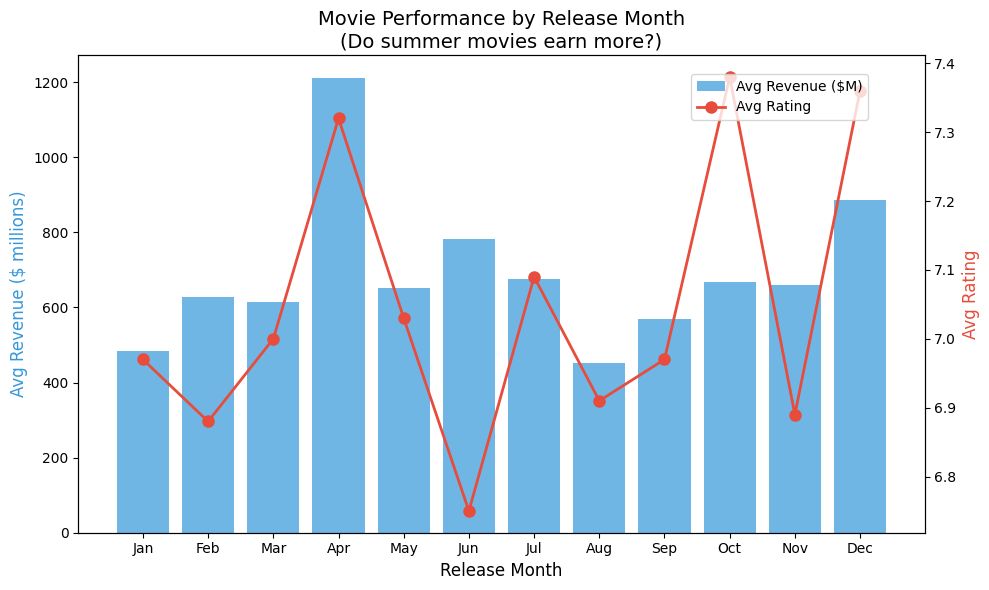

In [36]:
# Visualization 2: Average revenue by release month
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(df_monthly["release_month"], df_monthly["avg_revenue_M"],
        color="#3498db", alpha=0.7, label="Avg Revenue ($M)")
ax1.set_xlabel("Release Month", fontsize=12)
ax1.set_ylabel("Avg Revenue ($ millions)", fontsize=12, color="#3498db")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)

ax2 = ax1.twinx()
ax2.plot(df_monthly["release_month"], df_monthly["avg_rating"],
         "o-", color="#e74c3c", linewidth=2, markersize=8, label="Avg Rating")
ax2.set_ylabel("Avg Rating", fontsize=12, color="#e74c3c")

plt.title("Movie Performance by Release Month\n(Do summer movies earn more?)", fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig("viz_monthly_performance.png", dpi=150, bbox_inches="tight")
plt.show()

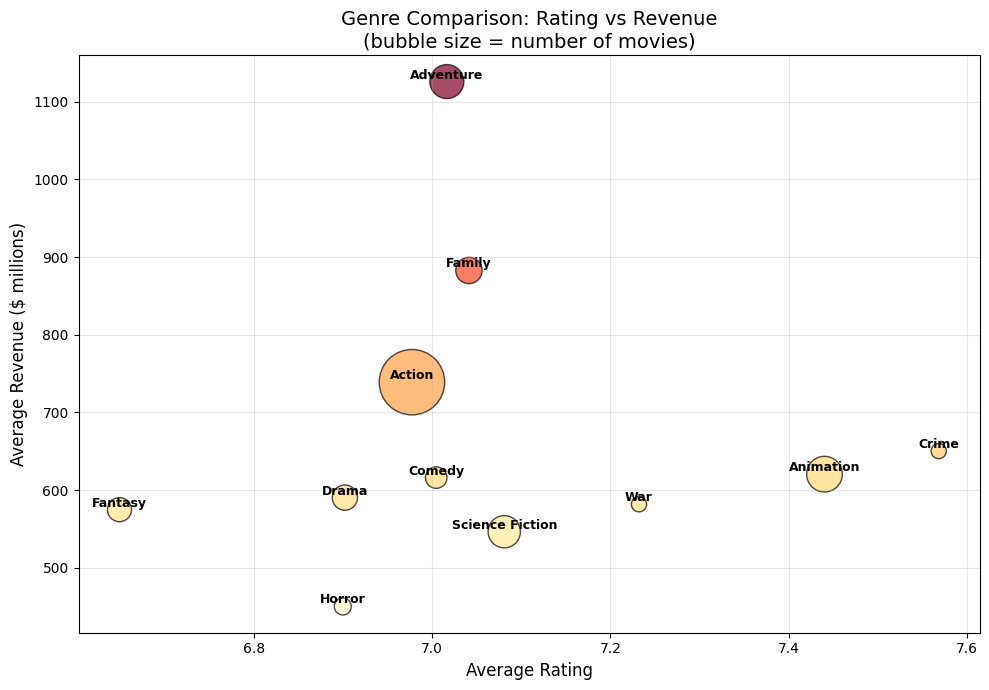

In [37]:
# Visualization 3: Genre comparison: rating vs revenue
df_genre = pd.read_sql("""
    SELECT primary_genre,
           COUNT(*) as count,
           AVG(vote_average) as avg_rating,
           AVG(revenue) / 1e6 as avg_revenue_M
    FROM movies
    WHERE budget > 0 AND revenue > 0
    GROUP BY primary_genre
    HAVING COUNT(*) >= 3
""", conn)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_genre["avg_rating"],
    df_genre["avg_revenue_M"],
    s=df_genre["count"] * 30,
    c=df_genre["avg_revenue_M"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=1
)

for _, row in df_genre.iterrows():
    ax.annotate(row["primary_genre"], (row["avg_rating"], row["avg_revenue_M"]),
                fontsize=9, ha="center", va="bottom", fontweight="bold")

ax.set_xlabel("Average Rating", fontsize=12)
ax.set_ylabel("Average Revenue ($ millions)", fontsize=12)
ax.set_title("Genre Comparison: Rating vs Revenue\n(bubble size = number of movies)", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("viz_genre_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4002/2656058703.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True)


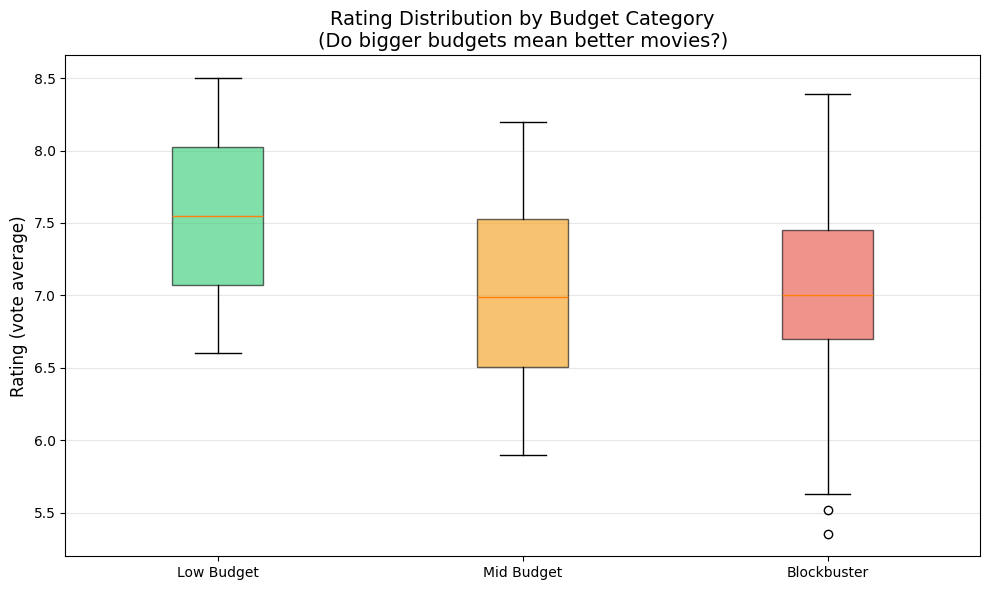

In [38]:
# Visualization 4: Rating distribution by budget category
fig, ax = plt.subplots(figsize=(10, 6))

categories = ["Low Budget", "Mid Budget", "Blockbuster"]
cat_colors = ["#2ecc71", "#f39c12", "#e74c3c"]

data_to_plot = []
for cat in categories:
    subset = df_enriched[(df_enriched["budget_category"] == cat)]
    data_to_plot.append(subset["vote_average"].dropna().values)

bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True)
for patch, color in zip(bp["boxes"], cat_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Rating (vote average)", fontsize=12)
ax.set_title("Rating Distribution by Budget Category\n(Do bigger budgets mean better movies?)", fontsize=14)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("viz_rating_by_budget.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Close database connection
conn.close()
print("Database connection closed. All outputs saved.")

Database connection closed. All outputs saved.


---
## Conclusions

### Key Findings
1. **Budget and revenue are correlated**: bigger budgets tend to mean higher revenue, but there are notable exceptions (low-budget hits and expensive flops).
2. **Summer and holiday months** (June, July, December) tend to generate higher average revenue.
3. **Genre matters**: Action and Adventure dominate in revenue, while Drama and Animation tend to have higher ratings.
4. **Genre co-occurrence** reveals natural clusters: Action-Adventure-Sci-Fi form a tight group, while Drama-Romance and Horror-Thriller are closely linked.
5. **Movie review sentiment** is mixed, with positive headlines often about award-winning films and negative ones about franchise fatigue.

### Data Engineering Techniques Used
| Technique | Where |
|---|---|
| API Data Ingestion | TMDb API (movies), REST Countries API (country metadata) |
| Web Scraping (BeautifulSoup) | Movie review headlines from Google News RSS |
| Regex (Data Cleaning) | Title cleaning, date extraction, format validation |
| SQL Database (SQLite) | 3 tables with JOINs, GROUP BY, nested queries, HAVING |
| PySpark Batch Processing | Categorization, aggregation, window functions (ranking) |
| Graph Analytics (NetworkX) | Genre co-occurrence network, centrality, community detection |
| NLP (HuggingFace BERT) | Sentiment analysis on review headlines |
| Visualization (Matplotlib) | Scatter, bar, box plots, and network graph |

### Reflection
- **Easy:** The TMDb API is well-documented and returns clean JSON data. SQL storage and queries were straightforward.
- **Challenging:** Rate limiting on the API required careful use of `time.sleep()`. Some movies had missing budget/revenue data.
- **Next time:** We could add streaming data (e.g., real-time trending movies) or include cast/director networks for richer graph analysis.